In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      12
  On-line CPU(s) list:       0-11
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      6
    Socket(s):               1
    Stepping:                7
    BogoMIPS:                4400.32
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                 

In [2]:
!nvidia-smi

Thu Apr 23 14:12:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")

PyTorch: 2.10.0+cu128
CUDA available: True
cuDNN version: 91002


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd drive/"MyDrive"/"Colab Notebooks"/"new_offRL"/"rl_v2_4"

/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_4


# ReBRAC formal Stage B screening

**定位**：ReBRAC 实验计划 ([docs/rebrac_experiment_plan.md §6.3](../docs/rebrac_experiment_plan.md)) 中 Stage B 的正式执行入口。

**前置**：Stage B0 训练预算 probe 已经确认 `TRAIN_EPOCHS=64` 足够（详见 [docs/rebrac_experiment_report.md §5](../docs/rebrac_experiment_report.md)）。本 notebook 沿用该预算，不再扫 epoch。

**目标**：回答一个问题——

> 在 `crosscomp-1000 / 2000` 上，ReBRAC 是否能在 `success_rate` 和 / 或 `std_test_success_rate` 上稳定不弱于 TD3BC phase0c 主线？

**协议**（与 TD3BC `phase0b_v2 / phase0c` Stage B 完全对齐）：

- 训练：`--eval-every 0 --skip-final-eval`，按 `CHECKPOINT_EVERY_EPOCHS=8` 保存 `agent_step_*.pt`
- 每个 ckpt 在独立 val manifest 上评估
- 按 `success_rate → return → -safety_cost → -time` 选最佳 ckpt
- 选中 ckpt 在 held-out test manifest 上重跑，作为该 (β1, β2, seed) 的 test 成绩
- summary 同时输出 `mean_critic_penalty`、`mean_target_q`、`mean_critic_penalty_ratio` 三列训练侧诊断

**本轮实验范围**：

| 轴 | 配置 | 说明 |
|---|---|---|
| β1 (actor penalty) | `1.0 / 2.0 / 4.0` | 对齐 TD3BC α = `0.5 / 0.25 / 0.125`；在 Q-normalized ReBRAC 口径下 β1 ≈ 1/(2·α) |
| β2 (critic penalty) | `1.0 / 2.0` | 两档覆盖 "critic penalty 轻量 vs 中等" 两种 regime |
| dataset | `crosscomp-1000`、`crosscomp-2000` | phase0c 主线的两个核心对照点 |
| seeds | `42 / 43 / 44` | 3 seeds 是暴露 seed 方差的最低门槛 |
| TRAIN_EPOCHS | `64` | Stage B0 已验证 |
| manifest | val = 40 / test = 40 | Stage B 协议 |

**预算**：`3 × 2 × 2 × 3 = 36` 个 train run；每个 run 另外 8 次 val 评估 + 1 次 test 评估。

**判据**（详见 [plan §6.3 判据](../docs/rebrac_experiment_plan.md)）：出现任何一条就算正信号，可以推进 Stage C。

1. `crosscomp-1000` 上 ReBRAC 稳定不弱于 TD3BC，且 success 或 return 至少一项更好；
2. `crosscomp-2000` 上 ReBRAC 明显优于当前 TD3BC 主线；
3. `2000` 至少不再比 `1000` 明显更差。

如果 3×2 全部弱于 TD3BC，**不建议**立刻扩网格，应先检查 `std_test_success_rate` 与 `mean_critic_penalty_ratio` 的分布再决定是小幅扩参还是直接转 XQL。


## 0. 环境配置

默认输出路径（与 Stage B0 probe 分开）：

- `checkpoints/offline/rebrac/screening/`
- `results/offline/rebrac/screening/`
- `results/offline/rebrac/screening/summaries/overview.csv`


In [6]:
import os

# —— 通用（与其它 ReBRAC / TD3BC 实验一致）——
os.environ["PYTHON_BIN"]         = "python3"
os.environ["DEVICE"]             = "cuda"
os.environ["EVAL_WORKERS"]       = "6"
os.environ["EVAL_WORKER_DEVICE"] = "cpu"

# —— 正式 screening 网格 ——
os.environ["DATASET_EPISODES"]        = "1000 2000"
os.environ["SEEDS"]                   = "42 43 44"
os.environ["ACTOR_PENALTY_COEFS"]     = "1.0 2.0 4.0"
os.environ["CRITIC_PENALTY_COEFS"]    = "1.0 2.0"
os.environ["TRAIN_EPOCHS"]            = "64"
os.environ["CHECKPOINT_EVERY_EPOCHS"] = "8"
os.environ["VAL_MANIFEST_EPISODES"]   = "40"
os.environ["TEST_MANIFEST_EPISODES"]  = "40"

# —— 输出目录（留默认即可；显式写出，方便后面直接 glob）——
os.environ["CHECKPOINT_ROOT"] = "checkpoints/offline/rebrac/screening"
os.environ["RESULTS_ROOT"]    = "results/offline/rebrac/screening"
os.environ["SUMMARY_ROOT"]    = "results/offline/rebrac/screening/summaries"

# 其余默认即可：BENCHMARK_KEY=single_u10_cross_tgt15,
# BASELINE_POLICY=crosscomp, PROBE_LAYOUT=s0, HISTORY_LENGTH=4,
# TASK_GEOMETRY=cross_stream, TARGET_SPEED=1.5, OBJECTIVE=efficiency_v2,
# SAMPLING_MODE=shuffle_no_replacement, BATCH_SIZE=256,
# critic_layernorm=on, actor_layernorm=off, normalize_q=on


## 1. 生成 val / test manifest

只跑一次。已经存在的文件会被跳过。如果 Stage B0 已经生成过同规模的 manifest（应该已经生成过），这一步会全部打印 `[skip]`。


In [7]:
os.environ["MODE"] = "manifests"
!bash scripts/run_offline_rebrac_screen.sh


[skip] manifest exists: benchmarks/offline_rebrac_screen/val_40/single_u10_cross_tgt15.json
[skip] manifest exists: benchmarks/offline_rebrac_screen/test_40/single_u10_cross_tgt15.json


## 2. 收集离线数据（crosscomp-1000、crosscomp-2000）

如果此前已经在 `offline_data/` 下生成过对应 dataset（phase0c 或 Stage B0 probe 都会生成），这一步会打印 `[skip] dataset exists`。


In [8]:
os.environ["MODE"] = "collect"
!bash scripts/run_offline_rebrac_screen.sh


[skip] dataset exists: offline_data/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/transitions.npz
[skip] dataset exists: offline_data/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep2000/transitions.npz


## 3. 全流程：train → validate → select → test → summarize

这一步产出：

- 36 个 train run（3 × 2 × 2 × 3）
- 每个 run 有 8 个 checkpoint × 40 val episodes = 320 val evaluations
- 每个 run 选出最佳 ckpt 后在 test 上跑一次
- summary 写入 `results/offline/rebrac/screening/summaries/overview.{csv,json}`

耗时主体是 train。已经存在的 artifacts 会被 skip，安全中断后重跑。


In [ ]:
os.environ["MODE"] = "all"
!bash scripts/run_offline_rebrac_screen.sh


Streaming output truncated to the last 5000 lines.
avg_progress_ratio    : 0.521 +/- 0.432
avg_path_efficiency   : 0.412 +/- 0.256
termination           : {'out_of_bounds': 36, 'goal': 2, 'timeout': 2}
benchmark_manifest    : benchmarks/offline_rebrac_screen/val_40/single_u10_cross_tgt15.json

[cmd] python3 -m scripts.evaluate_offline --checkpoint checkpoints/offline/rebrac/screening/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0/seed_44 --agent-file agent_step_00009552.pt --manifest benchmarks/offline_rebrac_screen/val_40/single_u10_cross_tgt15.json --device cuda --num-workers 6 --worker-device cpu --seed 123 --output-json results/offline/rebrac/screening/crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000/actorb_2p0__criticb_1p0/validation/seed_44/agent_step_00009552.json
reward_objective      : efficiency_v2
energy_cost_gain      : 0.000000
safety_cost_gain      : 0.250000
episodes              : 40
success_rate          : 30.0%
avg_retur

## 4. Overview 表：mean / std test success + 训练侧诊断

把 `summaries/overview.csv` 按 `(dataset, mean_test_success_rate desc)` 排序显示。关键列：

- `mean_test_success_rate` / `std_test_success_rate`：主判据
- `mean_test_return`：和 success 做交叉确认
- `mean_critic_penalty_ratio`：β2 权重**乘之前**的原始尺度，接近 1 说明 critic 会被 penalty 支配；显著小于 1 说明 penalty 是锦上添花
- `mean_critic_penalty` / `mean_target_q`：供手工检查


In [ ]:
import csv
from pathlib import Path

import pandas as pd

SUMMARY_CSV = Path(os.environ["SUMMARY_ROOT"]) / "overview.csv"

if not SUMMARY_CSV.exists():
    print(f"[missing] {SUMMARY_CSV} — run §3 first.")
else:
    df = pd.read_csv(SUMMARY_CSV)

    def _fmt(x, precision=4):
        try:
            return f"{float(x):.{precision}f}"
        except Exception:
            return str(x)

    display_cols = [
        "dataset",
        "pair",
        "num_seeds",
        "mean_test_success_rate",
        "std_test_success_rate",
        "mean_test_return",
        "std_test_return",
        "mean_test_safety_cost",
        "mean_test_time_s",
        "mean_critic_penalty",
        "mean_target_q",
        "mean_critic_penalty_ratio",
    ]
    view = df[display_cols].copy()
    view = view.sort_values(
        ["dataset", "mean_test_success_rate"], ascending=[True, False]
    ).reset_index(drop=True)
    # 4-digit precision for success / ratio columns; 2 for returns / time
    for col in [
        "mean_test_success_rate",
        "std_test_success_rate",
        "mean_critic_penalty_ratio",
    ]:
        view[col] = view[col].map(lambda v: _fmt(v, 4))
    for col in [
        "mean_test_return",
        "std_test_return",
        "mean_test_safety_cost",
        "mean_test_time_s",
        "mean_critic_penalty",
        "mean_target_q",
    ]:
        view[col] = view[col].map(lambda v: _fmt(v, 2))
    print(view.to_string(index=False))


                                                    dataset                    pair  num_seeds mean_test_success_rate std_test_success_rate mean_test_return std_test_return mean_test_safety_cost mean_test_time_s mean_critic_penalty mean_target_q mean_critic_penalty_ratio
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000 actorb_4p0__criticb_2p0          3                 0.8833                0.0312           -39.74            4.13                 15.97            78.84                0.08         -8.23                    0.0645
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000 actorb_2p0__criticb_2p0          3                 0.8500                0.1080           -46.01           13.36                 16.53            79.93                0.08         -5.51                    0.0177
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000 actorb_4p0__criticb_1p0          3                 0.8250                0.0890           -45.83            8.95            

## 5. β1 × β2 heatmap：success mean ± std

每个 dataset 画一张 `β1 × β2` 的热图，格子里写 `mean ± std`。颜色编码 mean，写在格子里的文字同时展示 mean / std，方便肉眼同时读方差。

**阅读方式**：

- 看每个 dataset 的 "最亮格子" 是不是就是 mean 最大的那一格（主判据）；
- 如果某个 β1 列的 std 明显更小（格子颜色接近均值但文字里 std 小），那是候选的 "方差最稳" 组合，也值得作为 Stage C 候选；
- 对比两个 dataset 的最亮格子位置——如果 `2000` 的最亮格子明显在 β1 更大的那一列，说明 ReBRAC 在 `2000` 上确实需要更弱的 BC 约束。


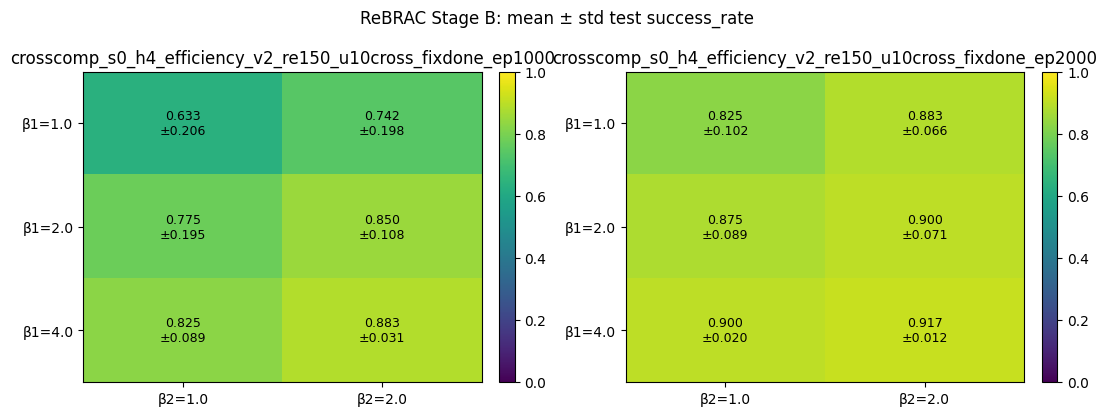

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if not SUMMARY_CSV.exists():
    print(f"[missing] {SUMMARY_CSV}")
else:
    ACTOR_BETAS  = [float(x) for x in os.environ["ACTOR_PENALTY_COEFS"].split()]
    CRITIC_BETAS = [float(x) for x in os.environ["CRITIC_PENALTY_COEFS"].split()]
    DATASETS = sorted(df["dataset"].unique())

    def _pair_tag(a, c):
        return f"actorb_{str(a).replace('.', 'p')}__criticb_{str(c).replace('.', 'p')}"

    fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.5 * len(DATASETS), 4.2))
    if len(DATASETS) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, DATASETS):
        mean_mat = np.full((len(ACTOR_BETAS), len(CRITIC_BETAS)), np.nan)
        std_mat  = np.full_like(mean_mat, np.nan)
        for i, b1 in enumerate(ACTOR_BETAS):
            for j, b2 in enumerate(CRITIC_BETAS):
                pair = _pair_tag(b1, b2)
                row = df[(df["dataset"] == dataset) & (df["pair"] == pair)]
                if not row.empty:
                    mean_mat[i, j] = float(row["mean_test_success_rate"].iloc[0])
                    std_mat[i, j]  = float(row["std_test_success_rate"].iloc[0])

        im = ax.imshow(mean_mat, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
        ax.set_xticks(range(len(CRITIC_BETAS)))
        ax.set_xticklabels([f"β2={b2}" for b2 in CRITIC_BETAS])
        ax.set_yticks(range(len(ACTOR_BETAS)))
        ax.set_yticklabels([f"β1={b1}" for b1 in ACTOR_BETAS])
        ax.set_title(dataset)
        for i in range(len(ACTOR_BETAS)):
            for j in range(len(CRITIC_BETAS)):
                if np.isnan(mean_mat[i, j]):
                    ax.text(j, i, "N/A", ha="center", va="center", color="red")
                else:
                    color = "white" if mean_mat[i, j] < 0.5 else "black"
                    ax.text(
                        j, i,
                        f"{mean_mat[i, j]:.3f}\n±{std_mat[i, j]:.3f}",
                        ha="center", va="center", color=color, fontsize=9,
                    )
        fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)

    fig.suptitle("ReBRAC Stage B: mean ± std test success_rate")
    fig.tight_layout()
    plt.show()


## 6. Per-seed 分布：检查 seed 方差假设

Stage B0 的重要发现是 seed 44 在 β1=2.0 下是 outlier。本节把每个 (dataset, β1, β2) 的三个 seed test success 单独展示出来，确认：

- 高 `std` 的格子是不是都 "有一个 seed 明显掉下来"；
- 某些 β1 列（例如 β1=4.0）是不是系统性地方差更小；
- 如果有一个 seed 在多个格子里都是 outlier，说明它可能是一个 "训练阶段某个早期随机决策不利" 的 seed，而不是配置问题。


In [ ]:
import json

RESULTS_ROOT = Path(os.environ["RESULTS_ROOT"])

def load_test_payload(dataset: str, pair: str, seed: str) -> dict | None:
    path = RESULTS_ROOT / dataset / pair / "test" / f"seed_{seed}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))

if not SUMMARY_CSV.exists():
    print(f"[missing] {SUMMARY_CSV}")
else:
    SEEDS = os.environ["SEEDS"].split()
    print(f"{'dataset':<18}{'pair':<28}" + "".join(f"seed_{s:<8}" for s in SEEDS) + "min-max spread")
    print("-" * (18 + 28 + 13 * len(SEEDS) + 14))
    for dataset in sorted(df["dataset"].unique()):
        sub = df[df["dataset"] == dataset].sort_values("mean_test_success_rate", ascending=False)
        for _, r in sub.iterrows():
            pair = r["pair"]
            per_seed = []
            for seed in SEEDS:
                payload = load_test_payload(dataset, pair, seed)
                if payload is None:
                    per_seed.append(None)
                else:
                    per_seed.append(float(payload["eval_success_rate"]))
            seed_cells = "".join(
                f"{v:<13.4f}" if v is not None else f"{'N/A':<13}" for v in per_seed
            )
            valid = [v for v in per_seed if v is not None]
            spread = (max(valid) - min(valid)) if len(valid) >= 2 else 0.0
            print(f"{dataset:<18}{pair:<28}{seed_cells}{spread:.4f}")


dataset           pair                        seed_42      seed_43      seed_44      min-max spread
---------------------------------------------------------------------------------------------------
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000actorb_4p0__criticb_2p0     0.8750       0.9250       0.8500       0.0750
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000actorb_2p0__criticb_2p0     0.9000       0.9500       0.7000       0.2500
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000actorb_4p0__criticb_1p0     0.8750       0.9000       0.7000       0.2000
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000actorb_2p0__criticb_1p0     0.9000       0.9250       0.5000       0.4250
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000actorb_1p0__criticb_2p0     0.9500       0.8000       0.4750       0.4750
crosscomp_s0_h4_efficiency_v2_re150_u10cross_fixdone_ep1000actorb_1p0__criticb_1p0     0.4750       0.9250       0.5000       0.4500
cr

## 7. Critic penalty 诊断：β2 · ratio 是否处在合理量级

[rebrac_experiment_plan.md §6.3 训练侧诊断](../docs/rebrac_experiment_plan.md) 给出的量级判读规则：

- `β2 · mean_critic_penalty_ratio` 接近 1 → critic 会被 penalty 支配，可能过度悲观
- `β2 · mean_critic_penalty_ratio` 显著低于 1 → penalty 是锦上添花，critic 主要靠真实 target Q 学习

本节把每个 (dataset, β1, β2) 的 `β2 · ratio` 画成条形图，并按 dataset 画一条参考虚线在 `1.0`。


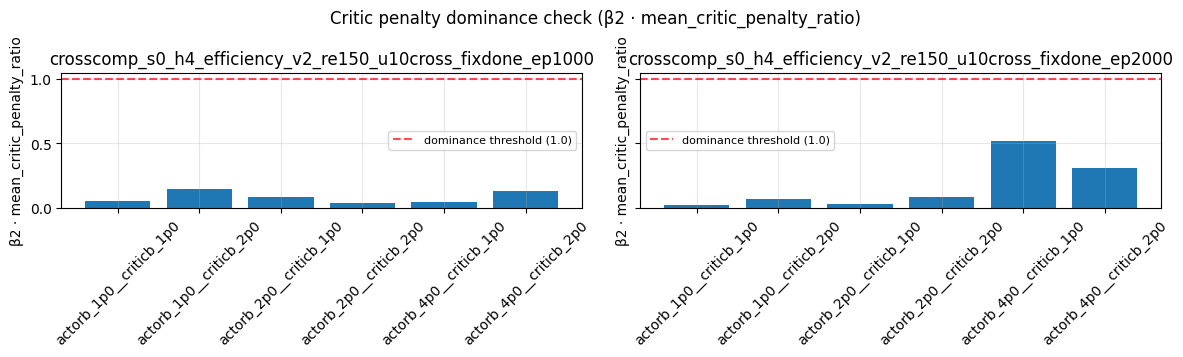

In [ ]:
if not SUMMARY_CSV.exists():
    print(f"[missing] {SUMMARY_CSV}")
else:
    fig, axes = plt.subplots(1, len(sorted(df["dataset"].unique())),
                              figsize=(6 * len(sorted(df["dataset"].unique())), 3.6),
                              sharey=True)
    if len(sorted(df["dataset"].unique())) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, sorted(df["dataset"].unique())):
        sub = df[df["dataset"] == dataset].copy()
        # β2 · ratio: reconstruct β2 from pair tag
        def _beta2_from_pair(pair):
            return float(pair.split("criticb_")[-1].replace("p", "."))
        sub["beta2"] = sub["pair"].map(_beta2_from_pair)
        sub["effective"] = sub["beta2"] * sub["mean_critic_penalty_ratio"]
        sub = sub.sort_values("pair")
        ax.bar(sub["pair"], sub["effective"])
        ax.axhline(1.0, linestyle="--", color="red", alpha=0.7, label="dominance threshold (1.0)")
        ax.set_title(dataset)
        ax.set_ylabel("β2 · mean_critic_penalty_ratio")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle("Critic penalty dominance check (β2 · mean_critic_penalty_ratio)")
    fig.tight_layout()
    plt.show()


## 8. Stage C finalist 决策规则

跑完上面所有单元后，用以下规则选出 **每个 dataset 的一个 finalist**（即 Stage C 要用正式 5-seed 复核的 `(β1, β2)` 组合）：

1. **主排序键**：`mean_test_success_rate` 最高。
2. **tiebreaker 1**：`std_test_success_rate` 最低（方差小优先）。
3. **tiebreaker 2**：`mean_test_return` 最高。
4. **一票否决**：`β2 · mean_critic_penalty_ratio > 1.5` 的格子不进 Stage C，除非它在 (1) (2) 两个维度上都是绝对第一。原因是 critic 已经被 penalty 支配，这种 "数值上最强" 的结果可能更多是 penalty 强制把 Q 拉到行为分布附近，而不是真的学到了更好的策略。
5. **对照**：finalist 必须与 TD3BC phase0c 同 dataset 的 winner 对照。

| dataset | TD3BC phase0c Stage C 正式成绩 | ReBRAC finalist 至少需要 |
|---|---|---|
| `crosscomp-1000` | `success 0.672 ± 0.045 @ α=0.25` | mean ≥ 0.672 **或** mean 相当但 std 更小 |
| `crosscomp-2000` | `success 0.596 ± 0.036 @ α=0.15` | mean > 0.596 **或** mean 相当且 std < 0.036 |

如果都达不到，按 [plan §10 推荐执行顺序](../docs/rebrac_experiment_plan.md) 直接停止扩 ReBRAC，转向 XQL；不要小幅扩网格兜底。

结果出来后，把 finalist 及其数字补进 [docs/rebrac_experiment_report.md](../docs/rebrac_experiment_report.md) 的 "Stage B" 章节（目前尚未写入）。
